This notebook contains a summary of results from our evaluations, including figures and performance metrics.

## Imports

In [ ]:
import matplotlib.pyplot as plt

## Baseline Comparisons

In [3]:
def plot_labo_vs_linear_probe(
    labo_scores,
    linear_probe_scores,
    title="",
    ylabel="Accuracy (%)",
    save_path=None,
):
    """
    Plot LaBo vs Linear Probe.
    """
    x_labels = ["1", "2", "4", "8", "16", "full"]

    assert len(labo_scores) == len(linear_probe_scores), "labo_scores and linear_probe_scores must have the same length."

    assert len(labo_scores) == len(x_labels), "Length of scores must match length of x_labels."

    x = list(range(len(x_labels)))

    fig, ax = plt.subplots(figsize=(4.2, 3.0))

    # Linear Probe
    ax.plot(
        x,
        linear_probe_scores,
        linestyle="--",
        marker="x",
        linewidth=1.0,
        markersize=5,
        color="black",
        label="Linear Probe",
    )

    # LaBo
    ax.plot(
        x,
        labo_scores,
        linestyle="-",
        marker="d",
        linewidth=1.2,
        markersize=4,
        color="purple",
        label="LaBo",
    )

    ax.set_title(title, fontsize=11)
    ax.set_xlabel("# of shots", fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, fontsize=9)
    ax.tick_params(axis="y", labelsize=9)

    ax.grid(True, linestyle="-", linewidth=0.5, alpha=0.35)
    ax.legend(fontsize=8, frameon=True, loc="lower right")
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

Food-101

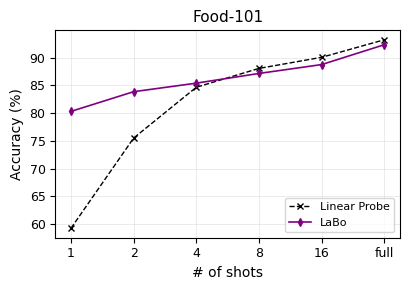

In [9]:
food_labo = [80.33, 83.88, 85.42, 87.17, 88.77, 92.35]
food_linear_probe = [59.261, 75.521, 84.68, 88.076, 90.079, 93.241]

plot_labo_vs_linear_probe(
    labo_scores=food_labo,
    linear_probe_scores=food_linear_probe,
    title="Food-101",
)

Flower-102

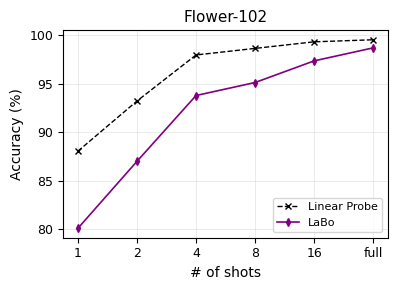

In [10]:
flower_labo = [80.11, 87.01, 93.79, 95.13, 97.36, 98.7]
flower_linear_probe = [88.056, 93.223, 97.967, 98.645, 99.322, 99.534]

plot_labo_vs_linear_probe(
    labo_scores=flower_labo,
    linear_probe_scores=flower_linear_probe,
    title="Flower-102",
)

CIFAR-10

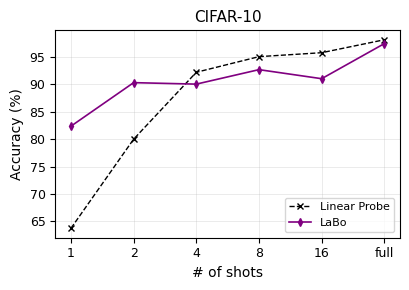

In [11]:
cifar_labo = [82.37, 90.31, 90.04, 92.68, 91.03, 97.43]
cifar_linear_probe = [63.75, 80.0, 92.2, 95.05, 95.77, 98.13]

plot_labo_vs_linear_probe(
    labo_scores=cifar_labo,
    linear_probe_scores=cifar_linear_probe,
    title="CIFAR-10",
)

CUB

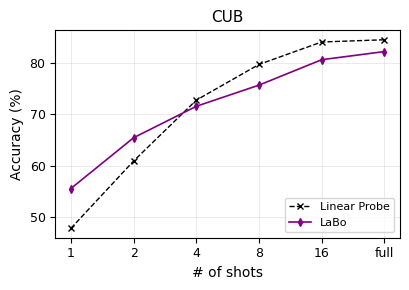

In [12]:
cub_labo = [55.61, 65.48, 71.59, 75.7, 80.64, 82.22]
cub_linear_probe = [47.877, 60.96, 72.782, 79.72, 84.087, 84.518]

plot_labo_vs_linear_probe(
    labo_scores=cub_labo,
    linear_probe_scores=cub_linear_probe,
    title="CUB",
)

In [17]:
def compute_avg_acc(food, flower, cifar, cub):
    x_labels = ["1", "2", "4", "8", "16", "full"]
    overall_avg = 0.0
    for i in range(len(x_labels)):
        avg_acc = (food[i] + flower[i] + cifar[i] + cub[i]) / 4
        overall_avg += avg_acc
        print(f"{x_labels[i]}-shot: {avg_acc:.2f}%")
    print(f"Overall Average: {overall_avg / len(x_labels):.2f}%")

LaBo

In [18]:
compute_avg_acc(food_labo, flower_labo, cifar_labo, cub_labo)

1-shot: 74.61%
2-shot: 81.67%
4-shot: 85.21%
8-shot: 87.67%
16-shot: 89.45%
full-shot: 92.68%
Overall Average: 85.21%


Linear Probe

In [19]:
compute_avg_acc(food_linear_probe, flower_linear_probe, cifar_linear_probe, cub_linear_probe)

1-shot: 64.74%
2-shot: 77.43%
4-shot: 86.91%
8-shot: 90.37%
16-shot: 92.31%
full-shot: 93.86%
Overall Average: 84.27%


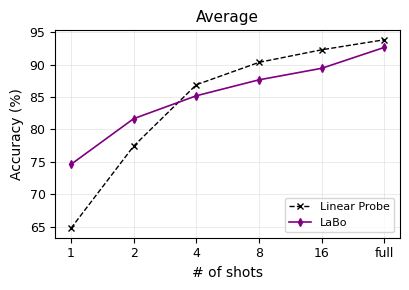

In [16]:
avg_labo = [74.61, 81.67, 85.21, 87.67, 89.45, 92.68]
avg_linear_probe = [64.74, 77.43, 86.91, 90.37, 92.31, 93.86]

plot_labo_vs_linear_probe(
    labo_scores=avg_labo,
    linear_probe_scores=avg_linear_probe,
    title="Average",
)

## FAITH@K

CIFAR-10

In [4]:
print('Original Concepts')
!python faith.py --input_json results/faithfulness_cifar10.json
print('\nVisually Grounded Concepts')
!python faith.py --input_json results/faithfulness_cifar10_new.json

Original Concepts



=== FAITH@k ===

--- ALL ---
Top-1: 0.490
Top-2: 0.495
Top-3: 0.450
Top-4: 0.450
Top-5: 0.438

Visually Grounded Concepts

=== FAITH@k ===

--- ALL ---
Top-1: 0.550
Top-2: 0.495
Top-3: 0.463
Top-4: 0.468
Top-5: 0.454


CUB

In [9]:
print('Original Concepts')
!python faith.py --input_json results/faithfulness_cub.json
print('\nVisually Grounded Concepts')
!python faith.py --input_json results/faithfulness_cub_new.json

Original Concepts

=== FAITH@k ===

--- ALL ---
Top-1: 0.699
Top-2: 0.683
Top-3: 0.680
Top-4: 0.674
Top-5: 0.672

Visually Grounded Concepts

=== FAITH@k ===

--- ALL ---
Top-1: 0.733
Top-2: 0.736
Top-3: 0.728
Top-4: 0.720
Top-5: 0.722


Flower-102

In [10]:
print('Original Concepts')
!python faith.py --input_json results/faithfulness_flower.json
print('\nVisually Grounded Concepts')
!python faith.py --input_json results/faithfulness_flower_new.json

Original Concepts

=== FAITH@k ===

--- ALL ---
Top-1: 0.726
Top-2: 0.747
Top-3: 0.746
Top-4: 0.745
Top-5: 0.747

Visually Grounded Concepts

=== FAITH@k ===

--- ALL ---
Top-1: 0.840
Top-2: 0.794
Top-3: 0.747
Top-4: 0.702
Top-5: 0.693


Food-101

In [11]:
print('Original Concepts')
!python faith.py --input_json results/faithfulness_food.json
print('\nVisually Grounded Concepts')
!python faith.py --input_json results/faithfulness_food_new.json

Original Concepts

=== FAITH@k ===

--- ALL ---
Top-1: 0.648
Top-2: 0.645
Top-3: 0.640
Top-4: 0.636
Top-5: 0.630

Visually Grounded Concepts

=== FAITH@k ===

--- ALL ---
Top-1: 0.696
Top-2: 0.674
Top-3: 0.642
Top-4: 0.609
Top-5: 0.590
